# Feature Engineering

Creating new features from existing ones to improve model performance.

In [15]:
# Imports
import pandas as pd
import numpy as np

# Load encoded data
df = pd.read_csv('../data/encoded_data.csv')
print('Encoded data loaded, shape:', df.shape)
df.head()

Encoded data loaded, shape: (10999, 16)


,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Product_importance_encoded,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Gender_M
0,1,0.0,2,-0.451220,0.0,2.0,-0.908270,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2,0.0,5,0.024390,-1.0,2.0,-0.330478,1,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,3,-1.0,2,-0.378049,1.0,2.0,-0.241395,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,-0.5,3,-0.463415,1.0,0.5,-0.925713,1,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,-1.0,2,-0.365854,0.0,2.0,-0.518611,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [16]:
# Create new features
# 1. Cost per weight
df['Cost_per_gram'] = df['Cost_of_the_Product'] / (df['Weight_in_gms'] + 1)  # +1 to avoid division by zero

# 2. Discount percentage
df['Discount_percentage'] = df['Discount_offered'] / (df['Cost_of_the_Product'] + 1) * 100

# 3. Customer engagement score
df['Customer_engagement'] = df['Customer_care_calls'] * df['Customer_rating']

# 4. Prior purchases category
df['Prior_purchases_category'] = pd.cut(df['Prior_purchases'], bins=[0, 2, 5, 10], labels=['low', 'medium', 'high'])

# 5. Is expensive product
df['Is_expensive'] = (df['Cost_of_the_Product'] > df['Cost_of_the_Product'].median()).astype(int)

print('New features created')
df[['Cost_per_gram', 'Discount_percentage', 'Customer_engagement', 'Prior_purchases_category', 'Is_expensive']].head()

New features created


,Cost_per_gram,Discount_percentage,Customer_engagement,Prior_purchases_category,Is_expensive
0,-4.918982,364.444444,0.0,NaN,0
1,0.036429,195.238095,0.0,NaN,1
2,-0.498348,321.568627,-2.0,low,0
3,-6.238124,93.181818,-1.5,low,0
4,-0.759996,315.384615,-2.0,NaN,0


In [17]:
# Encode the new categorical feature
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Prior_purchases_category_encoded'] = le.fit_transform(df['Prior_purchases_category'])
df = df.drop('Prior_purchases_category', axis=1)
print('Categorical feature encoded')

Categorical feature encoded


Correlations with target:
Cost_per_gram                      -0.172334
Is_expensive                       -0.062801
Customer_engagement                -0.052915
Prior_purchases_category_encoded    0.099572
Discount_percentage                 0.123975
Reached.on.Time_Y.N                 1.000000
Name: Reached.on.Time_Y.N, dtype: float64


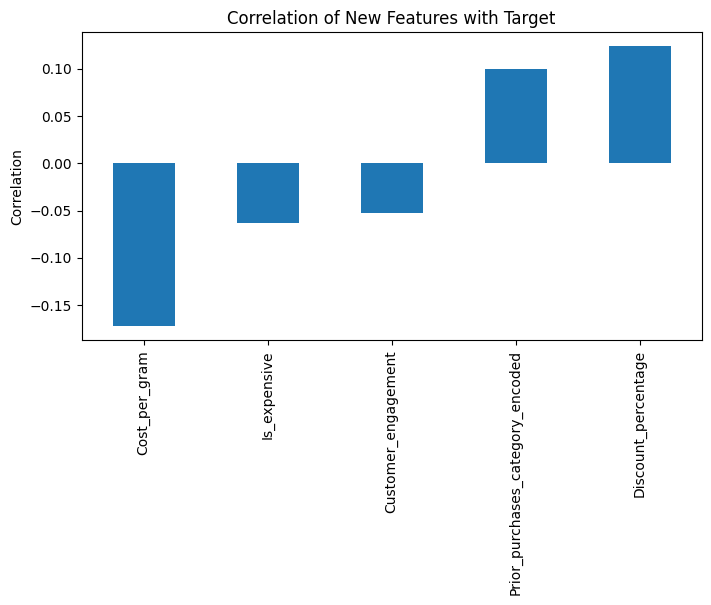

In [18]:
# Check correlations with new features
import matplotlib.pyplot as plt
import seaborn as sns

new_features = ['Cost_per_gram', 'Discount_percentage', 'Customer_engagement', 'Is_expensive', 'Prior_purchases_category_encoded']
corr_with_target = df[new_features + ['Reached.on.Time_Y.N']].corr()['Reached.on.Time_Y.N'].sort_values()
print('Correlations with target:')
print(corr_with_target)

# Plot
plt.figure(figsize=(8,4))
corr_with_target.drop('Reached.on.Time_Y.N').plot(kind='bar')
plt.title('Correlation of New Features with Target')
plt.ylabel('Correlation')
plt.show()

In [19]:
# Save engineered data
df.to_csv('../data/feature_engineered_data.csv', index=False)
print('Feature engineered data saved to ../data/feature_engineered_data.csv')
print('Final shape:', df.shape)

Feature engineered data saved to ../data/feature_engineered_data.csv
Final shape: (10999, 21)


In [20]:
import numpy as np

# Replace infinite values (inf, -inf) with NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Fill missing values using column mean (for numerical stability)
df = df.fillna(df.select_dtypes(include=np.number).mean())

# Save the cleaned dataset for use in modeling notebooks
df.to_csv('../data/final_cleaned_data.csv', index=False)

# Fill categorical columns with mode (most frequent value)
for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])
    
print("Clean dataset saved")

Clean dataset saved
